# Depandancy Package

In [1]:
import os
import time
import numpy as np

import mne
from mne.channels import make_standard_montage
# from mne.decoding import CSP

import sklearn
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import scipy
from scipy import stats
from scipy.io import loadmat
from scipy.signal import welch

from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns


print(f"numpy version: {np.__version__}")
print(f"mne version: {mne.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")
start_time = time.time()

numpy version: 2.2.6
mne version: 1.10.1
sklearn version: 1.7.2
scipy version: 1.15.3


# Dataset Setting

In [2]:
# Select dataset
# 0: BCICIV_2a
# 1: BCICIV_2b
# 2: BCICIV_1
Dataset_Selection = 1


match Dataset_Selection:
    case 0:
        gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
        mat_dirPath = None
        participants = [] # EEG-MI 受試者
        participantsNum = 9 # EEG-MI 受試者人數
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'A0{i}T']  # bci4_2A
        saveResultPath = './result_bci4_2a/' # 結果儲存資料夾
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2A 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG-Fz' : 'Fz'  ,
            'EEG-0'  : 'FC3' ,
            'EEG-1'  : 'FC1' ,
            'EEG-2'  : 'FCz' ,
            'EEG-3'  : 'FC2' ,
            'EEG-4'  : 'FC4' ,
            'EEG-5'  : 'C5'  ,
            'EEG-C3' : 'C3'  ,
            'EEG-6'  : 'C1'  ,
            'EEG-Cz' : 'Cz'  ,
            'EEG-7'  : 'C2'  ,
            'EEG-C4' : 'C4'  ,
            'EEG-8'  : 'C6'  ,
            'EEG-9'  : 'CP3' ,
            'EEG-10' : 'CP1' ,
            'EEG-11' : 'CPz' ,
            'EEG-12' : 'CP2' ,
            'EEG-13' : 'CP4' ,
            'EEG-14' : 'P1'  ,
            'EEG-Pz' : 'Pz'  ,
            'EEG-15' : 'P2'  ,
            'EEG-16' : 'POz' ,
            'EOG-left'   : 'EOG-left',
            'EOG-central': 'EOG-central',
            'EOG-right'  : 'EOG-right'
        }
        channel_types = {
            'EEG-Fz' : 'eeg',
            'EEG-0'  : 'eeg',
            'EEG-1'  : 'eeg',
            'EEG-2'  : 'eeg',
            'EEG-3'  : 'eeg',
            'EEG-4'  : 'eeg',
            'EEG-5'  : 'eeg',
            'EEG-C3' : 'eeg',
            'EEG-6'  : 'eeg',
            'EEG-Cz' : 'eeg',
            'EEG-7'  : 'eeg',
            'EEG-C4' : 'eeg',
            'EEG-8'  : 'eeg',
            'EEG-9'  : 'eeg',
            'EEG-10' : 'eeg',
            'EEG-11' : 'eeg',
            'EEG-12' : 'eeg',
            'EEG-13' : 'eeg',
            'EEG-14' : 'eeg',
            'EEG-Pz' : 'eeg',
            'EEG-15' : 'eeg',
            'EEG-16' : 'eeg',
            'EOG-left'   : 'eog',
            'EOG-central': 'eog',
            'EOG-right'  : 'eog'
        }
        downsamplingFreq = None
    case 1:
        gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'
        mat_dirPath = None
        participants = []
        participantsNum = 9
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'B0{i}03T']  # bci4_2B
        saveResultPath = './result_bci4_2b/'
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG:C3' : 'C3'  ,
            'EEG:Cz' : 'Cz'  ,
            'EEG:C4' : 'C4'  ,
            'EOG:ch01':'EOG:ch01',
            'EOG:ch02':'EOG:ch02',
            'EOG:ch03':'EOG:ch03'
        }
        channel_types = {
            'EEG:C3'   : 'eeg',
            'EEG:Cz'   : 'eeg',
            'EEG:C4'   : 'eeg',
            'EOG:ch01' : 'eog',
            'EOG:ch02' : 'eog',
            'EOG:ch03' : 'eog'
        }
        downsamplingFreq = None
    case 2:
        gdf_dirPath = None
        mat_dirPath = f'../../dataset/BCICIV_1calib_1000Hz_mat/'
        participants = []
        participantsNum = 3
        participantsId = ['b','c','g']
        for i in participantsId:
            participants = participants + [f'BCICIV_calib_ds1{i}_1000Hz']  # bci4_1
        saveResultPath = './result_bci4_1/'
        target_keys = ['Left', 'Right'] # 任務
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = None
        channel_types = None
        downsamplingFreq = 250

try:
    os.mkdir(saveResultPath) # 創建結果儲存資料夾
    os.mkdir(saveResultPath +'./confuseMatrix/') # 創建結果儲存資料夾
except:
    print("file exist")
    pass

file exist


# Pre-Processing Setting

In [3]:
# band pass filter
fs = 250
lowcut = 1
highcut = 30
filter_order = 4
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 擷取實驗時間，0秒是cued開始
# C: number of channels
# P: number of temporal points
# N: number of trials
# (tmax-tmin)*250+1=500
# tmax = (P-1)/fs+tmin
time_interval = 4
P = time_interval*fs
tmin = 0.5
tmax = (P-1)/fs+tmin
print(f"Time from {tmin} s to {tmax} s, sample point: {P}")

# CSP M值
M = 3

Time from 0.5 s to 4.496 s, sample point: 1000


# Data Segmentation

In [4]:
montage = make_standard_montage('standard_1020')
if channel_rename_map:
    eeg_only_channels = [
        name
        for name in channel_rename_map.values()
        if not name.startswith('EOG')
    ]

## Create Epoch training data and testing data
epochs = {}
for subject in participants:
    if gdf_dirPath:
        gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
        try:
            raw = mne.io.read_raw_gdf(gdf_filepath, preload=True, verbose="ERROR")
        except Exception as e:
            print(f"讀取 GDF 檔案時發生錯誤: {e}")
            raise
    elif mat_dirPath:
        try:
            mat_filepath = mat_dirPath + f'./{subject}.mat'
            mat_data = loadmat(mat_filepath, struct_as_record=False, squeeze_me=True)
            eeg_data = mat_data['cnt']     # 這是訊號矩陣 (Time x Channels)
            sfreq = mat_data['nfo'].fs     # 採樣率
            ch_names = mat_data['nfo'].clab # 通道名稱
            classes = mat_data['nfo'].classes
            events_sample = mat_data['mrk'].pos - 1
            events_id = np.where(mat_data['mrk'].y == -1, 1, 2)

            info = mne.create_info(ch_names=list(ch_names), sfreq=sfreq, ch_types='eeg', verbose='Error')
            raw = mne.io.RawArray(eeg_data.T * 1e-6, info, verbose='Error')

            events = np.column_stack((
                events_sample,
                np.zeros_like(events_sample, dtype=int),
                events_id.astype(int)
            ))
            mapping = {1: 'Left', 2: 'Right'}
            annot = mne.annotations_from_events(
                events=events,
                sfreq=raw.info['sfreq'],
                event_desc=mapping
            )
            raw.set_annotations(annot)
        except Exception as e:
            print(f"讀取 GDF 檔案時發生錯誤: {e}")
            raise

    ## Raw setting
    if channel_types:
        raw.set_channel_types(channel_types, verbose="ERROR") # 設定電擊種類是EEG還是EOG
    if channel_rename_map:
        raw.rename_channels(channel_rename_map, verbose="ERROR") # 重新命名電擊名稱符合10-20系統
    if downsamplingFreq:
        raw.resample(sfreq=downsamplingFreq) # downsampling
    raw.set_eeg_reference([], verbose="ERROR") # 設定reference電擊
    raw.set_montage(montage, on_missing='ignore', verbose="ERROR") # 設定10-20系統

    ## Regression
    # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    # model.fit(raw)
    # raw = model.apply(raw)
    if channel_rename_map:
        raw.pick_channels(eeg_only_channels, verbose="ERROR") # Remove EOG data
    raw.filter( # Bandpass filter
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',
        iir_params=iir_params,
        verbose="ERROR"
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    new_id_mapping = {old_id: i for i, old_id in enumerate(kept_event_ids.values())}
    kept_event_ids = {key: i for i, key in enumerate(kept_event_ids.keys())}
    for i in range(len(events_of_interest)):
        old_val = events_of_interest[i, 2]
        events_of_interest[i, 2] = new_id_mapping[old_val]

    baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
    epoch = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False,           # 暫時不應用投影
        verbose="ERROR"
    )
    epochs[subject] = epoch
    print(f"{subject} epoch create successful")

B0103T epoch create successful
B0203T epoch create successful
B0303T epoch create successful
B0403T epoch create successful
B0503T epoch create successful
B0603T epoch create successful
B0703T epoch create successful
B0803T epoch create successful
B0903T epoch create successful


# Feature Transfer (CSP)

In [5]:
class CSP(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=4, reg=1e-10):
        self.n_components = n_components
        self.reg = reg # 我們推導中的 gamma
        self.filters_ = None

    def __trace_normalization(self, X):
        '''
        Calculate the covariance for each trial and normalization trace
        ---------
        X: input data, (trials, chs, samples)
        trace_norm_cov: return data, (trials, chs, chs)
        '''
        X_T = np.transpose(X, (0,2,1))
        cov = X @ X_T
        trace = np.trace(cov, axis1=1, axis2=2).reshape(cov.shape[0], 1, 1)
        trace_norm_cov = cov/trace
        return trace_norm_cov

    def __covarianc_mean(self, X):
        '''
        Calculate the covariance for each trial and return their average
        ---------
        X: input data, covariance matrix, (trials, chs, chs)
        cov_mean: return data, mean of the covariance, (chs, chs)
        '''
        cov_mean = np.mean(X, axis=0)
        return cov_mean

    def fit(self, X, y):
        '''
        X: input data, (trials, chs, samples)
        y: input label, (trials)
        ---------
        訓練csp轉移矩陣儲存到self.filter
        '''
        ntrials, nchannels, nsamples = X.shape
        # 1. 準備數據：拆分兩類
        class1 = X[y == 0]
        class2 = X[y == 1]
        class1 = self.__trace_normalization(class1)
        class2 = self.__trace_normalization(class2)

        # 2. 計算各自的平均協方差矩陣
        # (epochs, channels, times) -> (channels, channels)
        cov_1 = self.__covarianc_mean(class1)
        cov_2 = self.__covarianc_mean(class2)

        sigma_total = cov_1 + cov_2
        eigenvalues, U = np.linalg.eigh(sigma_total)
        P = U @ np.diag((np.maximum(eigenvalues, 0) + self.reg) ** -0.5) @ U.T
        transformed_cov = P.T @ cov_1 @ P
        evals, B = np.linalg.eigh(transformed_cov)
        ix = np.argsort(evals)[::-1]

        # 3. 選擇n個csp
        if 2*self.n_components < nchannels:
            half = self.n_components // 2
            head_idx = ix[:self.n_components-half]
            tail_idx = ix[-half:]
            ix_selected = np.concatenate([head_idx, tail_idx])
            W = (P @ B)[:, ix_selected]
        else:
            W = (P @ B)
        W = W.T
        self.filters_ = W
        return self

    def transform(self, epochs_data):
        '''
        應用空間濾波器: Z = W * X
        feat_log: output, (trials, p)
        p: the number of feature selected
        '''
        feat = []
        for e in epochs_data:
            feat.append(np.dot(self.filters_, e))
        feat = np.array(feat)
        feat_var = np.var(feat, axis=2)
        feat_log = np.log(feat_var + 1e-10)
        return feat_log

# Log Sum PSD (LSP)

In [6]:
class LSP(BaseEstimator, TransformerMixin):
    def __init__(self, sf, band, window_sec=None, relative=False):
        self.sf = sf
        self.band = band
        self.window_sec = window_sec
        self.relative = relative

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        '''
        X shape: (trials, channels, samples)
        welch 預設對最後一個軸 (samples) 做變換
        psd shape: (trials, channels, freqs)
        '''
        low, high = self.band
        if self.window_sec is not None:
            nperseg = int(self.window_sec * self.sf)
        else:
            nperseg = int((2 / low) * self.sf)

        freqs, psd = welch(X, self.sf, nperseg=nperseg, axis=-1)
        idx_band = np.logical_and(freqs >= low, freqs <= high)
        freq_res = freqs[1] - freqs[0]
        bp = np.sum(psd[:, :, idx_band], axis=-1) * freq_res
        if self.relative:
            total_power = np.sum(psd, axis=-1) * freq_res
            bp /= (total_power + 1e-10) # 防止除以 0
        return bp

# Data Splitting

In [7]:
trainData = {}
testData = {}
seed = 42
for subject in participants:
    X = epochs[subject].get_data() # trials,chs,samples
    X = X - np.mean(X, axis=-1, keepdims=True)
    y = epochs[subject].events[:, 2]

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y)

    trainData[subject] = {
        'Data': X_train,
        'Label': y_train
    }

    testData[subject] = {
        'Data': X_test,
        'Label': y_test
    }


# Ablation

In [ ]:
class Ablation():
    def __init__(self):
        self.variants = ["Full", "no_CSP", "no_Alpha", "no_Beta", "Only_CSP"]
        self.ablate_configs = {
            "Full":      {"use_csp": True,  "use_alpha": True,  "use_beta": True},
            "no_CSP":   {"use_csp": False, "use_alpha": True,  "use_beta": True},
            "no_Alpha": {"use_csp": True,  "use_alpha": False, "use_beta": True},
            "no_Beta":  {"use_csp": True,  "use_alpha": True,  "use_beta": False},
            "Only_CSP":  {"use_csp": True,  "use_alpha": False, "use_beta": False},
        }

    def get_ablation_pipeline(self, M=3, use_csp=True, use_alpha=True, use_beta=True):
        # 1. 建立動態特徵清單
        features_list = []

        if use_csp:
            features_list.append(('csp_part', CSP(n_components=2*M)))
        if use_alpha:
            features_list.append(('lsp_alpha', LSP(sf=250, band=[8, 13], relative=True)))
        if use_beta:
            features_list.append(('lsp_beta', LSP(sf=250, band=[13, 30], relative=True)))

        # 2. 封裝成 FeatureUnion
        combined_features = FeatureUnion(features_list)

        # 3. 回傳完整的 Pipeline
        return Pipeline([
            ('features', combined_features),
            ('scaler', StandardScaler()),
            ('clf', LDA()),
        ])

    def ablation(func):
        def wrap(*args, **kwargs):
            results = {}
            for var in variants:
                pipe = get_ablation_pipeline(M=3, use_csp=ablate_configs[var]["use_csp"], use_alpha=ablate_configs[var]["use_alpha"], use_beta=ablate_configs[var]["use_beta"])
                result = func(pipe = pipe, *args, **kwargs)
                results[var] = result
            return results
        return wrap


# Train & Testing

In [9]:
@ablation
def train(pipe = None):
    result = {}
    for subject in participants:
        if not pipe:
            combined_features = FeatureUnion([
                ('csp_part', CSP(n_components=2*M)),
                ('lsp_alpha', LSP(sf=250, band=[8, 13], relative=True)), # 提取 Alpha 波
                ('lsp_beta', LSP(sf=250, band=[13, 30], relative=True)),   # 提取 Beta 波
            ])
            pipe = Pipeline([
                ('features', combined_features),
                ('scaler', StandardScaler()), # 不同的特徵量級不同，一定要 Scaler
                ('clf', LDA()),
            ])

        # 評估模型穩定度
        X = epochs[subject].get_data()
        y = epochs[subject].events[:, 2]
        cv_scores = cross_val_score(pipe, trainData[subject]['Data'], trainData[subject]['Label'], cv=5)

        # 評估泛化能力
        pipe.fit(trainData[subject]['Data'], trainData[subject]['Label'])
        test_scores = pipe.score(testData[subject]['Data'], testData[subject]['Label'])
        y_pred = pipe.predict(testData[subject]['Data'])
        conf_matrix = confusion_matrix(testData[subject]['Label'], y_pred)

        result[subject] = {
            'cv_scores': cv_scores,
            'test_conf': conf_matrix
        }

    return result

In [10]:
results = train()

# Report Analysis

In [ ]:
def analysis(result, output_filename = None):
    test_acc_all = {}
    test_precision_all = {}
    test_recall_all = {}
    test_f1_all = {}
    test_kappa_all = {}
    for subject in participants:
        test_acc_all[subject] = []
        test_precision_all[subject] = []
        test_recall_all[subject] = []
        test_f1_all[subject] = []
        test_kappa_all[subject] = []

    # 計算每個人的統計指標
    for subject in participants:
        TP = result[subject]['test_conf'][0][0]
        TN = result[subject]['test_conf'][0][1]
        FN = result[subject]['test_conf'][1][0]
        FP = result[subject]['test_conf'][1][1]
        test_trials = result[subject]['test_conf'].sum()

        test_acc  = (TP+FP)/test_trials
        test_precision = TP/(TP+FN)
        test_recall = TP/(TP+TN)
        test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
        test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
        test_kappa = (test_acc-test_pe)/(1-test_pe)

        test_acc_all[subject]       = round(test_acc*100,1)
        test_precision_all[subject] = round(test_precision*100,1)
        test_recall_all[subject]    = round(test_recall*100,1)
        test_f1_all[subject]        = round(test_f1,2)
        test_kappa_all[subject]     = round(test_kappa,2)


    test_acc_all['avg']         = round(np.mean(list(test_acc_all.values())), 1)
    test_precision_all['avg']   = round(np.mean(list(test_precision_all.values())), 1)
    test_recall_all['avg']      = round(np.mean(list(test_recall_all.values())), 1)
    test_f1_all['avg']          = round(np.mean(list(test_f1_all.values())), 2)
    test_kappa_all['avg']       = round(np.mean(list(test_kappa_all.values())), 2)

    test_acc_all['std']         = round(np.std(list(test_acc_all.values())), 1)
    test_precision_all['std']   = round(np.std(list(test_precision_all.values())), 1)
    test_recall_all['std']      = round(np.std(list(test_recall_all.values())), 1)
    test_f1_all['std']          = round(np.std(list(test_f1_all.values())), 2)
    test_kappa_all['std']       = round(np.std(list(test_kappa_all.values())), 2)

    # 創建表格
    data = {
        'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
        'Accuracy' : [f"{test_acc_all[subject]:.1f}" for subject in participants] + [test_acc_all['avg']] + [test_acc_all['std']],
        'Precision': [f"{test_precision_all[subject]:.1f}" for subject in participants] + [test_precision_all['avg']] + [test_precision_all['std']],
        'Recall'   : [f"{test_recall_all[subject]:.1f}" for subject in participants] + [test_recall_all['avg']] + [test_recall_all['std']],
        'F1-score' : [f"{test_f1_all[subject]:.2f}" for subject in participants] + [f"{test_f1_all['avg']:.2f}"] + [test_f1_all['std']],
        'Kappa'    : [f"{test_kappa_all[subject]:.2f}" for subject in participants] + [f"{test_kappa_all['avg']:.2f}"] + [test_kappa_all['std']]
    }

    df = pd.DataFrame(data)

    print("--- testing for generalization ---")
    print(df)
    if not output_filename:
        output_filename = saveResultPath + './stat_results_testing.csv'

    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )

    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return df

def robust_analysis(results):
    variants = ["Full", "no_CSP", "no_Alpha", "no_Beta", "Only_CSP"]
    analysis_results = {}
    cv_scores = {}
    for var in variants:
        cv_scores[var] = []
        for subject in participants:
            cv_scores[var].append(results[var][subject]['cv_scores']*100)
        cv_scores[var] = np.array(cv_scores[var])

    # 創建表格
    data = {
        'Subject'  : participants + ['Avg.'] + ['Std.'],
        variants[0]: np.round(np.concatenate((cv_scores[variants[0]].mean(axis=1), [cv_scores[variants[0]].mean(), cv_scores[variants[0]].std()])), decimals=1),
        variants[1]: np.round(np.concatenate((cv_scores[variants[1]].mean(axis=1), [cv_scores[variants[1]].mean(), cv_scores[variants[1]].std()])), decimals=1),
        variants[2]: np.round(np.concatenate((cv_scores[variants[2]].mean(axis=1), [cv_scores[variants[2]].mean(), cv_scores[variants[2]].std()])), decimals=1),
        variants[3]: np.round(np.concatenate((cv_scores[variants[3]].mean(axis=1), [cv_scores[variants[3]].mean(), cv_scores[variants[3]].std()])), decimals=1),
        variants[4]: np.round(np.concatenate((cv_scores[variants[4]].mean(axis=1), [cv_scores[variants[4]].mean(), cv_scores[variants[4]].std()])), decimals=1),

    }
    df = pd.DataFrame(data)
    print("--- cv score for robustness ---")
    print(df)
    output_filename = saveResultPath + './stat_results_cv.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )
    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return df

## robust

In [12]:
robust_analysis(results)
print()

--- cv score for robustness ---
   Subject  Full  no_CSP  no_Alpha  no_Beta  Only_CSP
0   B0103T  74.2    79.6      76.6     78.9      75.8
1   B0203T  56.3    55.5      57.8     61.6      58.6
2   B0303T  45.3    41.3      51.6     45.4      55.4
3   B0403T  96.9    97.7      97.7     96.2      94.6
4   B0503T  86.7    89.0      87.5     71.1      66.5
5   B0603T  71.1    76.6      75.8     71.8      61.5
6   B0703T  89.8    85.1      90.6     88.3      88.2
7   B0803T  82.7    85.1      82.0     84.3      84.3
8   B0903T  82.7    84.3      84.3     82.7      84.3
9     Avg.  76.2    77.1      78.2     75.6      74.4
10    Std.  16.6    17.7      15.3     16.0      15.0

數據已成功匯出到 './result_bci4_2b/./stat_results_cv.csv'。



In [13]:
variants = ["Full", "no_CSP", "no_Alpha", "no_Beta", "Only_CSP"]
analysis_results = {}
for var in variants:
    output_filename = saveResultPath + f"./stat_results_{var}_testing.csv"
    analysis_results[var] = analysis(results[var], output_filename=output_filename)

--- testing for generalization ---
   Subject Accuracy Precision Recall F1-score Kappa
0   B0103T     78.1      76.5   81.2     0.79  0.56
1   B0203T     56.2      55.0   68.8     0.61  0.12
2   B0303T     53.1      52.9   56.2     0.55  0.06
3   B0403T     96.9     100.0   93.8     0.97  0.94
4   B0503T     90.6      88.2   93.8     0.91  0.81
5   B0603T     81.2      85.7   75.0     0.80  0.62
6   B0703T     81.2      75.0   93.8     0.83  0.62
7   B0803T     90.6      84.2  100.0     0.91  0.81
8   B0903T     75.0      78.6   68.8     0.73  0.50
9     Avg.     78.1      77.3   81.3     0.79  0.56
10    Std.     13.4      13.6   13.4     0.13  0.27

數據已成功匯出到 './result_bci4_2b/./stat_results_Full_testing.csv'。
--- testing for generalization ---
   Subject Accuracy Precision Recall F1-score  Kappa
0   B0103T     78.1      80.0   75.0     0.77   0.56
1   B0203T     53.1      52.6   62.5     0.57   0.06
2   B0303T     46.9      47.4   56.2     0.51  -0.06
3   B0403T    100.0     100.0  1

## Compare Mean Acc for Ablation

In [ ]:
def test_compare():
    variants = ["Full", "no_CSP", "no_Alpha", "no_Beta", "Only_CSP"]
    accuracy = []
    xlabel = []
    for var in variants:
        accuracy.append(analysis_results[var]['Accuracy'])
        xlabel.append(var)
    data = {
            'Subject'  : participants + ['Avg', 'Std'],
            variants[0] : accuracy[0],
            variants[1] : accuracy[1],
            variants[2] : accuracy[2],
            variants[3] : accuracy[3],
            variants[4] : accuracy[4],
        }

    df = pd.DataFrame(data)

    print("--- Generalization Acc---")
    print(df)
    output_filename = saveResultPath + './stat_results_acc.csv'
    df.to_csv(
        output_filename,
        index=False        # 設置 index=False 來忽略 DataFrame 的索引列
    )
    print(f"\n數據已成功匯出到 '{output_filename}'。")
    return df


In [15]:
test_compare()
print()

--- Generalization Acc---
   Subject  Full no_CSP no_Alpha no_Beta Only_CSP
0   B0103T  78.1   78.1     78.1    84.4     81.2
1   B0203T  56.2   53.1     59.4    56.2     56.2
2   B0303T  53.1   46.9     62.5    50.0     62.5
3   B0403T  96.9  100.0    100.0    96.9     87.5
4   B0503T  90.6   90.6     87.5    68.8     59.4
5   B0603T  81.2   84.4     78.1    75.0     78.1
6   B0703T  81.2   81.2     68.8    78.1     75.0
7   B0803T  90.6   90.6     90.6    84.4     90.6
8   B0903T  75.0   81.2     75.0    68.8     78.1
9      Avg  78.1   78.5     77.8    73.6     74.3
10     Std  13.4   15.6     11.9    13.1     11.0

數據已成功匯出到 './result_bci4_2b/./stat_results_acc.csv'。



# Visualization

In [16]:
def preprocess_filename(filename: str, existed: str = "overwrite") -> str:
    if existed == "overwrite":
        pass
    elif existed == "keep_both":
        base, ext = os.path.splitext(filename)
        cnt = 1
        while os.path.exists(filename):
            filename = f"{base}-{cnt}{ext}"
            cnt += 1
    elif existed == "raise" and os.path.exists(filename):
        raise FileExistsError(f"{filename} already exists.")
    else:
        raise ValueError(f"Unknown value for 'existed': {existed}")
    return filename

def plot_confusion_matrix(conf_matrix, classes, filename=None):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix for Motor imagery")
    plt.tight_layout()
    if filename:
        filename = preprocess_filename(filename)
        plt.savefig(filename)
    print(f"Confusion matrix saved to {filename}")

In [17]:
def ablation_comparison(analysis_results):
    variants = ["Full", "no_CSP", "no_Alpha", "no_Beta", "Only_CSP"]
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'kappa']
    accuracy = []
    precision = []
    recall = []
    f1 = []
    kappa = []
    results = {}
    categories = []
    for var in variants:
        accuracy.append(float(analysis_results[var]['Accuracy'][participantsNum]))
        precision.append(float(analysis_results[var]['Precision'][participantsNum]))
        recall.append(float(analysis_results[var]['Recall'][participantsNum]))
        f1.append(float(analysis_results[var]['F1-score'][participantsNum]))
        kappa.append(float(analysis_results[var]['Kappa'][participantsNum]))
        categories.append(var)
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kappa': kappa,
    }

    colors = ["#000000", "#383838", "#6f6f6f", "#9C9C9C", "#b6b7b7"]

    for metric in metrics:
        plt.figure(figsize=(5, 4))
        plt.bar(
            categories,
            results[metric],
            color=colors,
        )
        if metric == 'f1' or metric == 'kappa':
            ymin = 0
            ymax = 1
        else:
            ymin = min(results[metric])-5
            ymax = max(results[metric])+5
        plt.ylim(ymin, ymax)
        plt.xlabel("Categories")
        plt.ylabel(metric)
        plt.title(f"{metric} for Ablation")
        plt.tight_layout()

        filename = saveResultPath +f"ablation_{metric}.png"
        if filename:
            filename = preprocess_filename(filename)
            plt.savefig(filename)
        print(f"Confusion matrix saved to {filename}")

Confusion matrix saved to ./result_bci4_2b/ablation_accuracy.png
Confusion matrix saved to ./result_bci4_2b/ablation_precision.png
Confusion matrix saved to ./result_bci4_2b/ablation_recall.png
Confusion matrix saved to ./result_bci4_2b/ablation_f1.png
Confusion matrix saved to ./result_bci4_2b/ablation_kappa.png


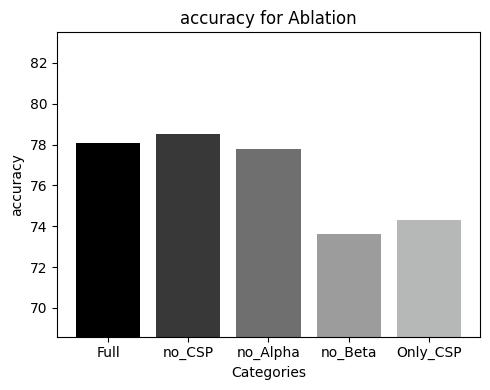

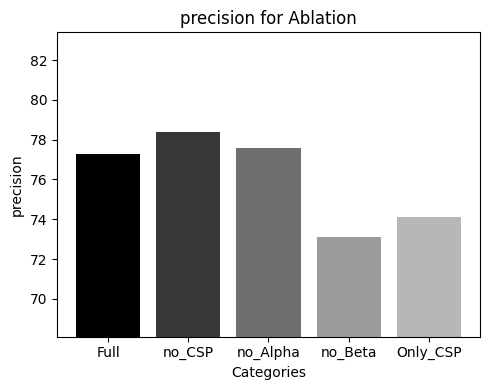

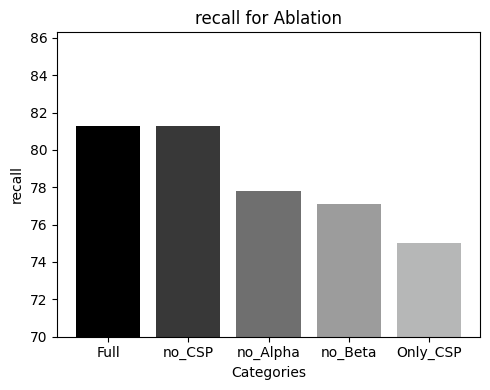

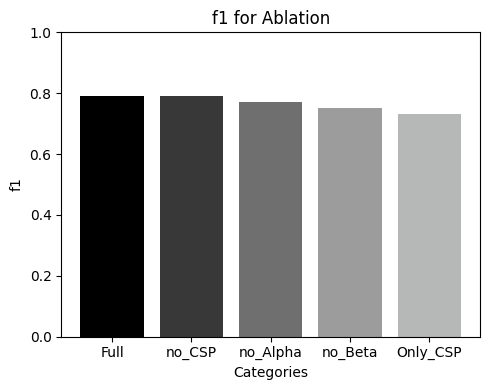

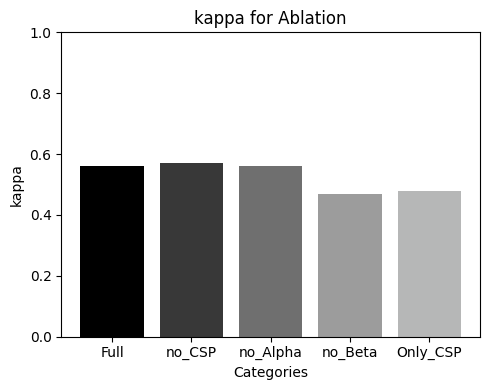

In [18]:
ablation_comparison(analysis_results)

Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0103T_Full.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0103T_no_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0103T_no_Alpha.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0103T_no_Beta.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0103T_Only_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0203T_Full.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0203T_no_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0203T_no_Alpha.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0203T_no_Beta.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0203T_Only_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0303T_Full.png
Confusion matrix 

C:\Users\User\AppData\Local\Temp\ipykernel_27252\1402370512.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5, 4))


Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0503T_Full.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0503T_no_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0503T_no_Alpha.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0503T_no_Beta.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0503T_Only_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0603T_Full.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0603T_no_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0603T_no_Alpha.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0603T_no_Beta.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0603T_Only_CSP.png
Confusion matrix saved to ./result_bci4_2b/./confuseMatrix/conf_matrix_B0703T_Full.png
Confusion matrix 

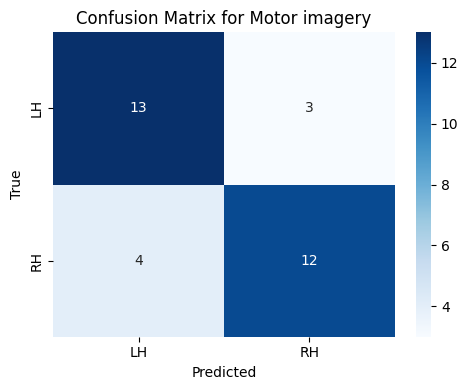

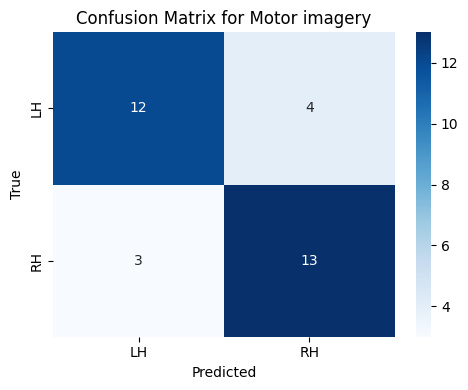

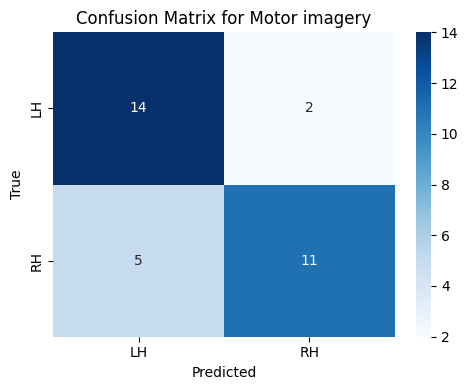

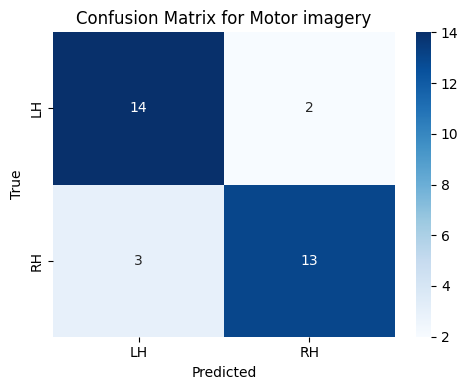

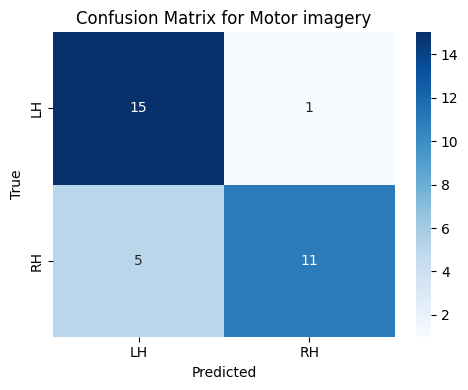

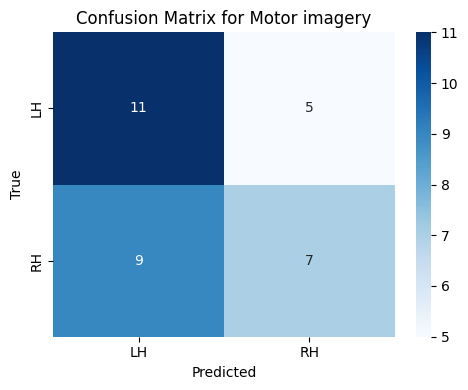

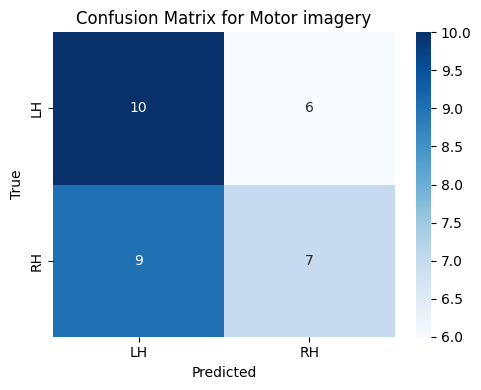

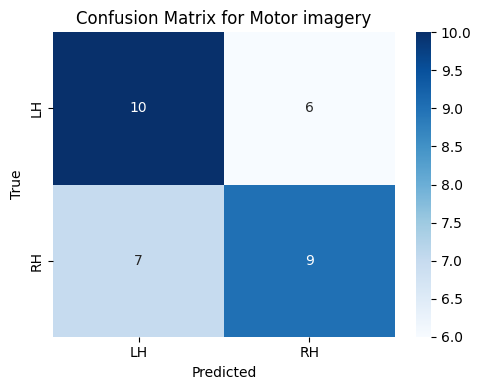

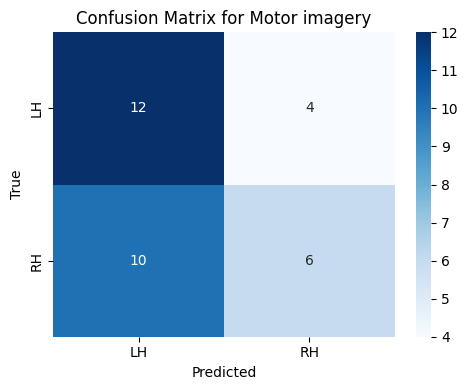

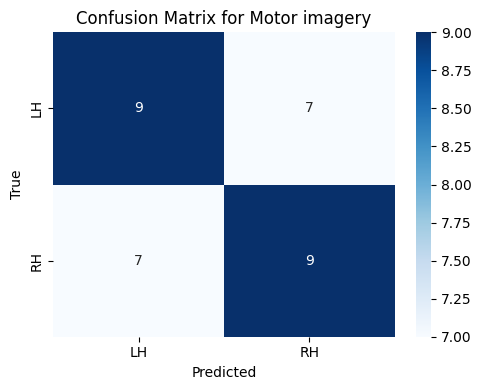

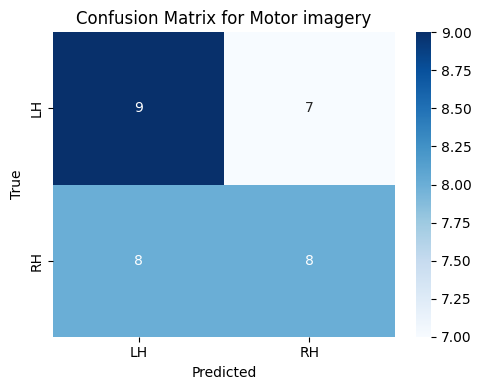

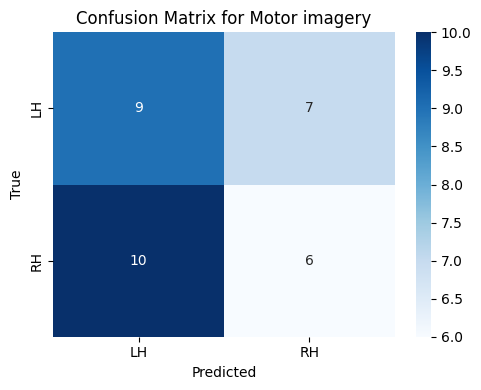

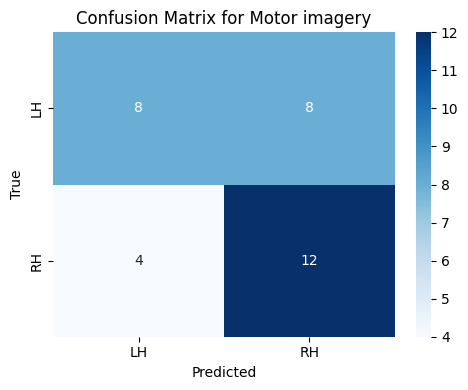

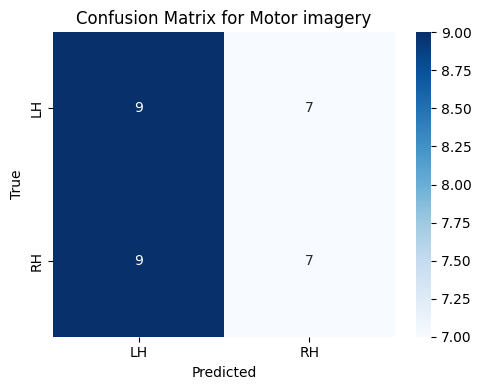

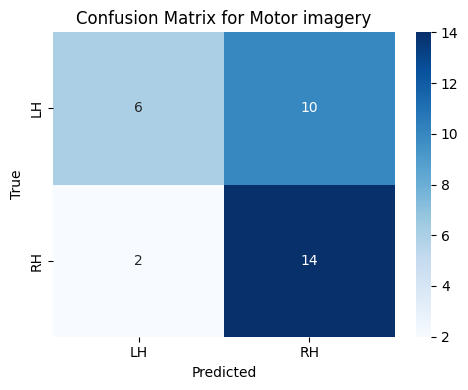

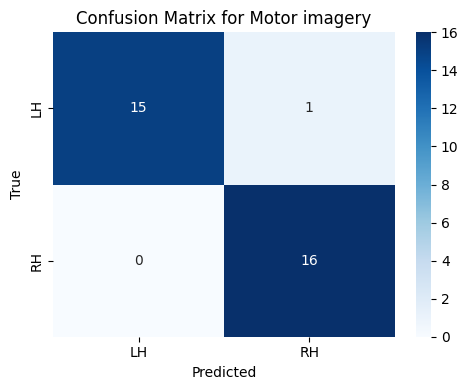

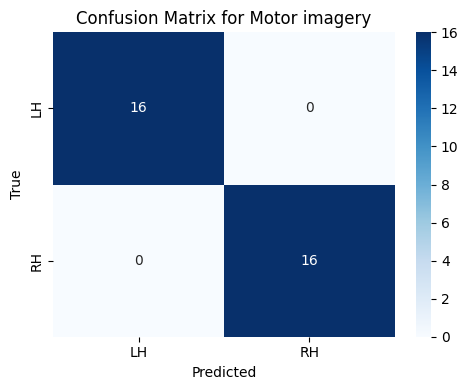

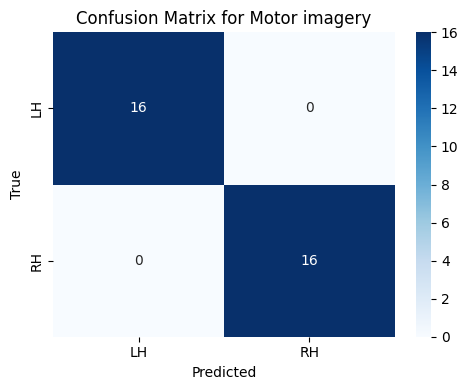

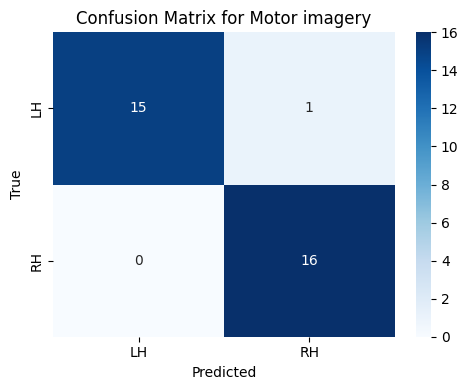

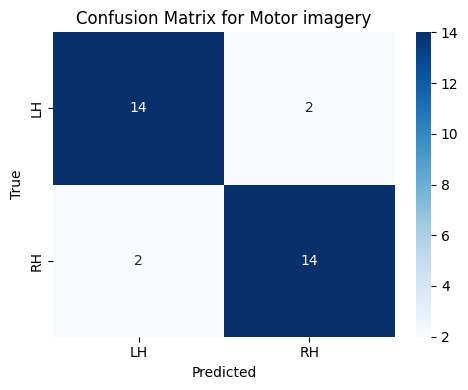

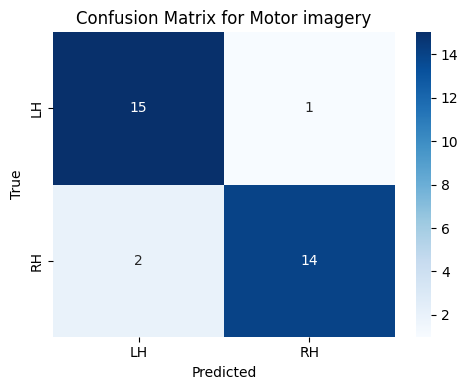

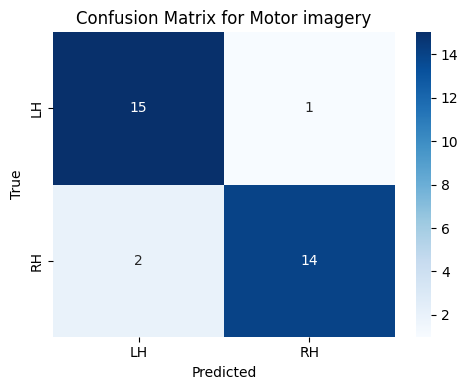

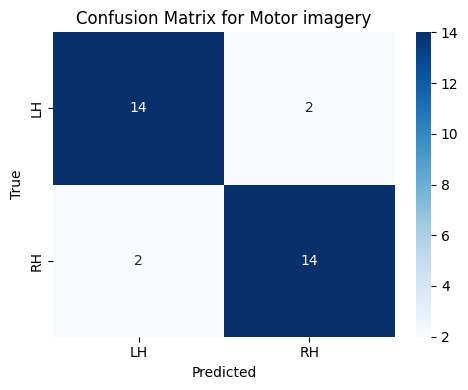

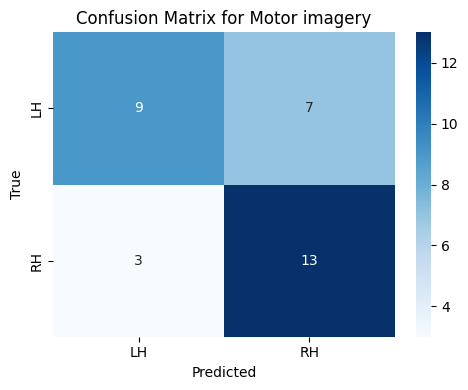

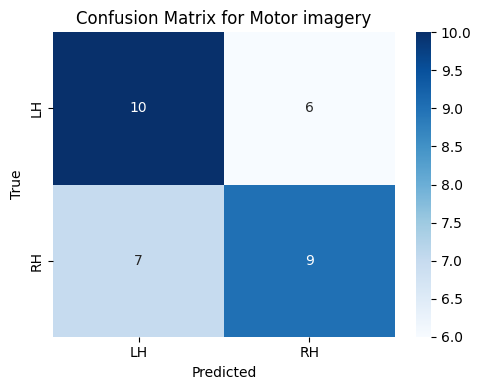

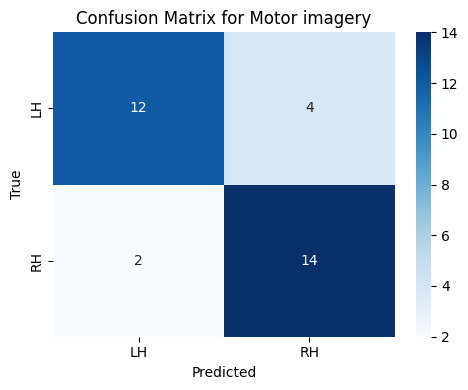

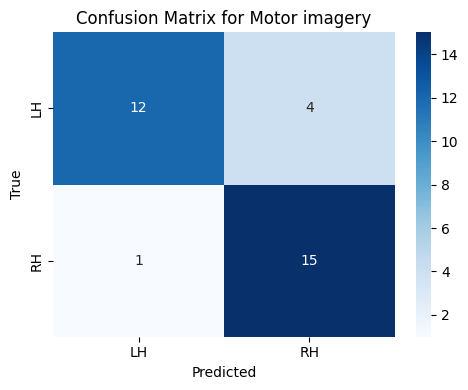

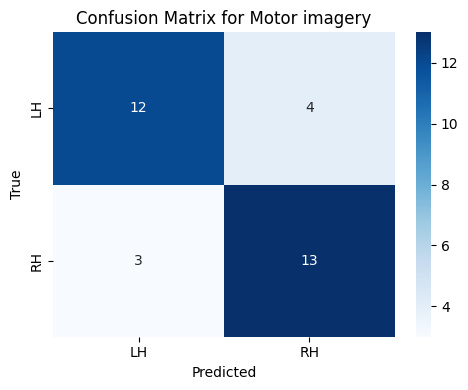

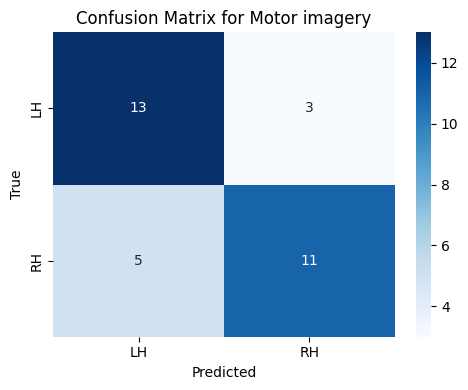

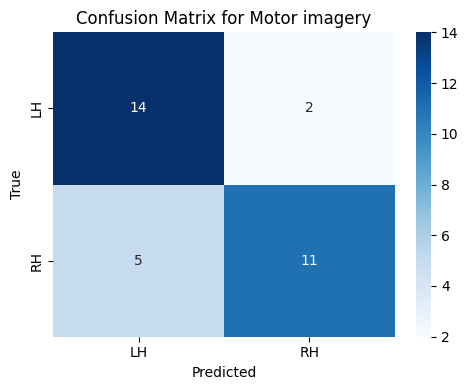

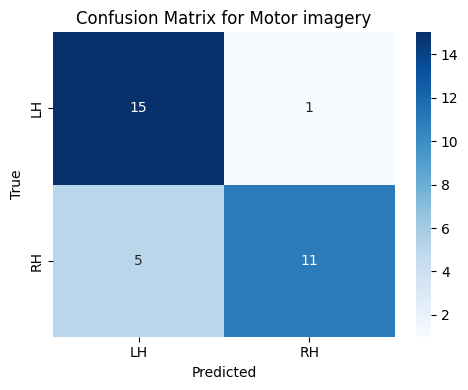

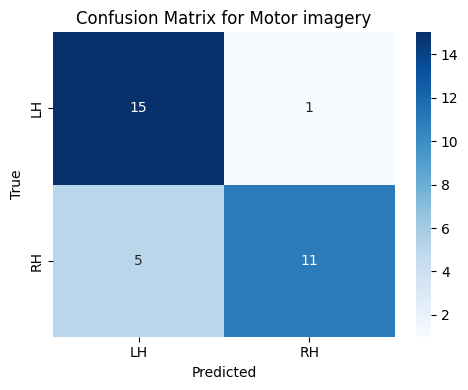

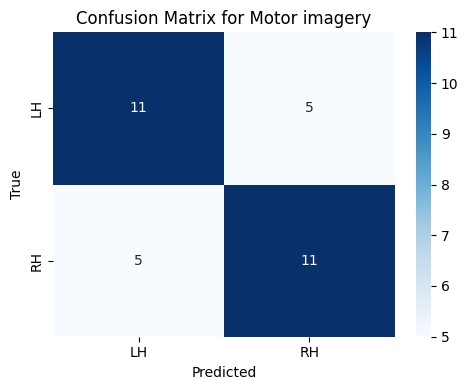

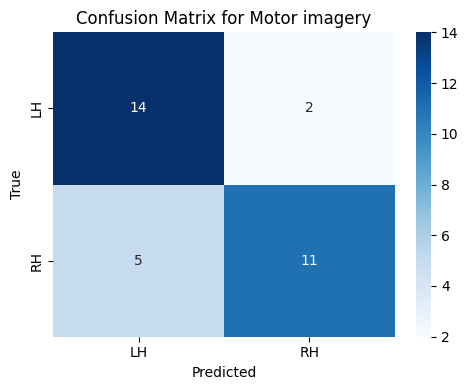

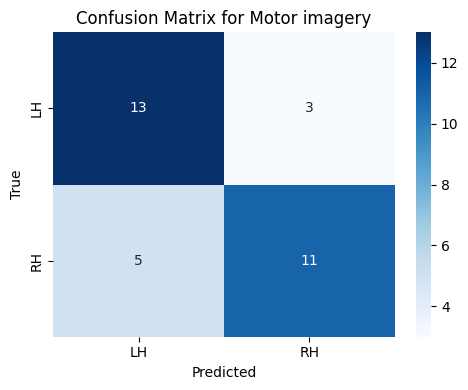

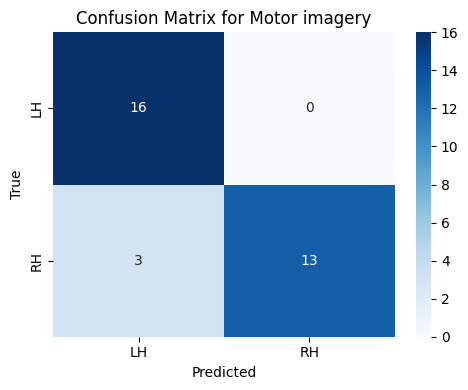

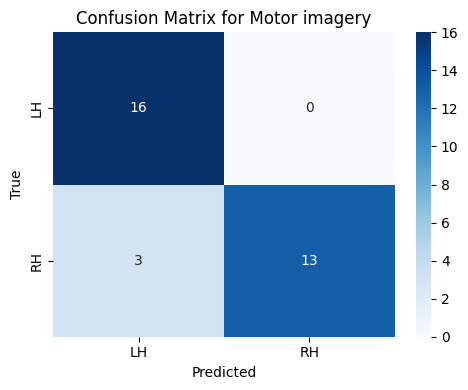

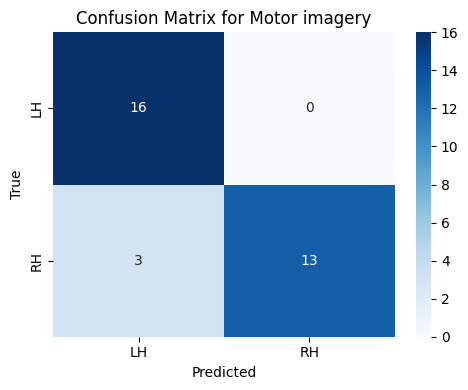

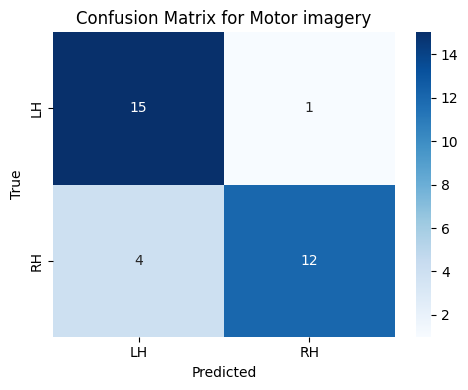

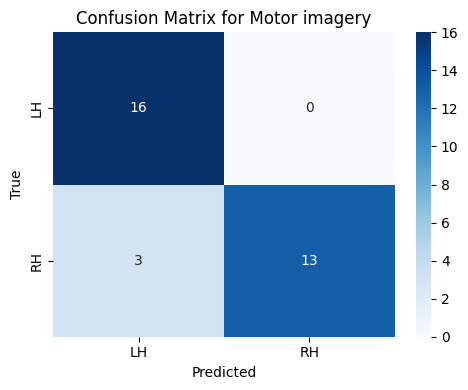

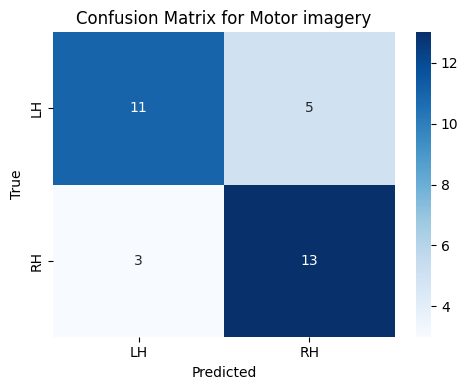

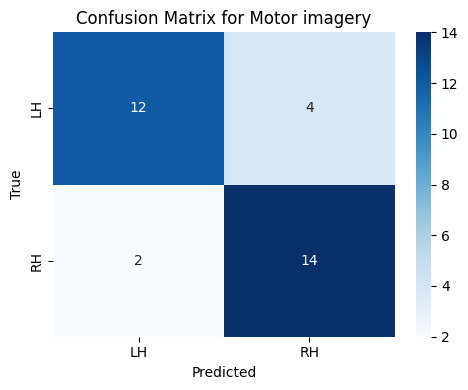

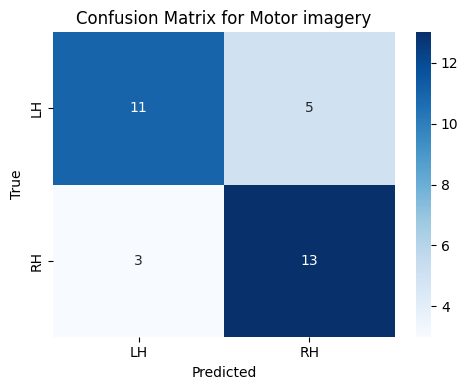

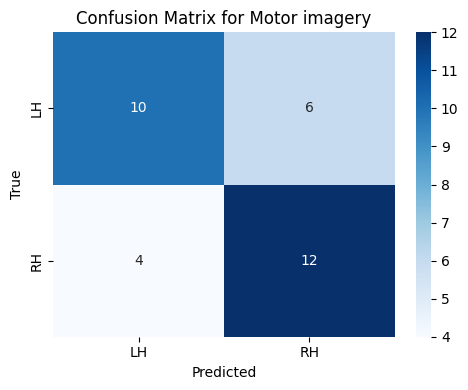

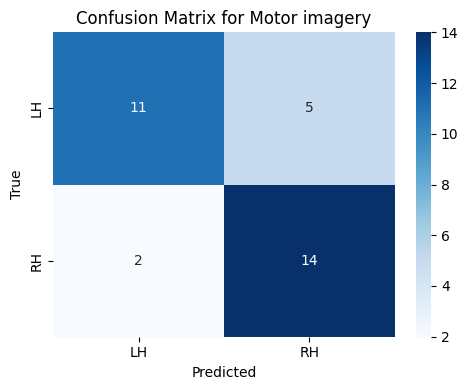

In [19]:
variants = ["Full", "no_CSP", "no_Alpha", "no_Beta", "Only_CSP"]
for subject in participants:
    for var in variants:
        classes = ['LH', 'RH']
        filename = saveResultPath +'./confuseMatrix/' + f"conf_matrix_{subject}_{var}.png"
        plot_confusion_matrix(results[var][subject]['test_conf'], classes, filename)

# End

In [20]:
end_time = time.time()
duration = end_time - start_time
print(f"--- 處理完成 ---")
print(f"總共花費時間: {duration:.4f} 秒")

--- 處理完成 ---
總共花費時間: 16.4999 秒
